# Desafío - Prediciendo los precios de las casas

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## 2. Carga de datos

In [2]:
df = pd.read_excel("house_data.xlsx")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.shape

(21613, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## 3. Análisis de calidad de datos

En esta sección se revisan valores nulos, duplicados, tipos de datos y posibles inconsistencias.

In [5]:
# Revisión de valores nulos
df.isna().sum().sort_values(ascending=False)

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [6]:
# Revisión de duplicados
df.duplicated().sum()

np.int64(0)

In [7]:
# Estadística descriptiva general
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


### Limpieza inicial

Se crea una copia del DataFrame original para trabajar sin modificar la base original.  
También se transforma la variable `date` a formato fecha y se extraen variables útiles como año y mes de venta.

In [8]:
df_clean = df.copy()

# Transformar fecha a datetime
df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

# Crear variables temporales
df_clean["sale_year"] = df_clean["date"].dt.year
df_clean["sale_month"] = df_clean["date"].dt.month

# Eliminar columnas poco útiles para el modelo
# id es un identificador y date ya fue transformada en año/mes
df_clean = df_clean.drop(columns=["id", "date"])

df_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


### Revisión de valores atípicos

Se revisan posibles outliers en la variable objetivo `price`.  
En precios de casas es normal encontrar valores altos, por lo que no todos los outliers son errores.  
Aun así, se aplica una limpieza moderada con el método IQR para evitar que valores extremadamente altos afecten demasiado a los modelos lineales.

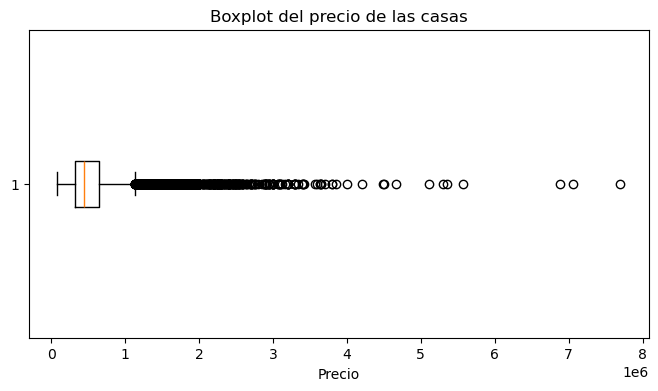

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_clean["price"], vert=False)
plt.title("Boxplot del precio de las casas")
plt.xlabel("Precio")
plt.show()

In [10]:
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

df_clean = df_clean[
    (df_clean["price"] >= limite_inferior) &
    (df_clean["price"] <= limite_superior)
]

df_clean.shape

Límite inferior: -162625.0
Límite superior: 1129575.0


(20467, 21)

En el plotbox se puede apreciar que hay muchos valores outsiders.

## 4. Análisis exploratorio de datos

Se analiza la distribución del precio y la relación entre variables numéricas.

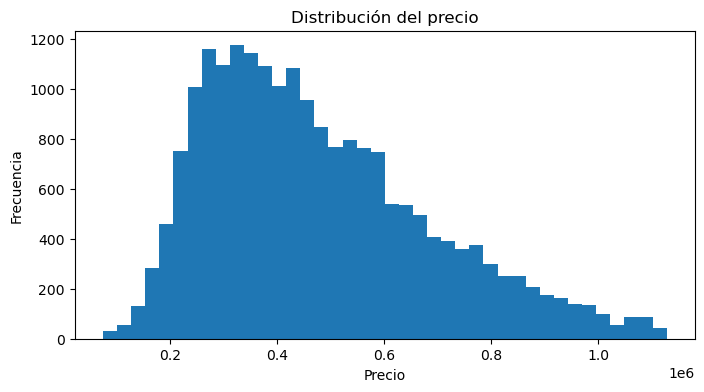

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean["price"], bins=40)
plt.title("Distribución del precio")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

La media de casas oscila entre 0.3 y 0.4 por 1e6 en precio. luego se ve una clara baja en la cantidad de casas por encima de este precio.

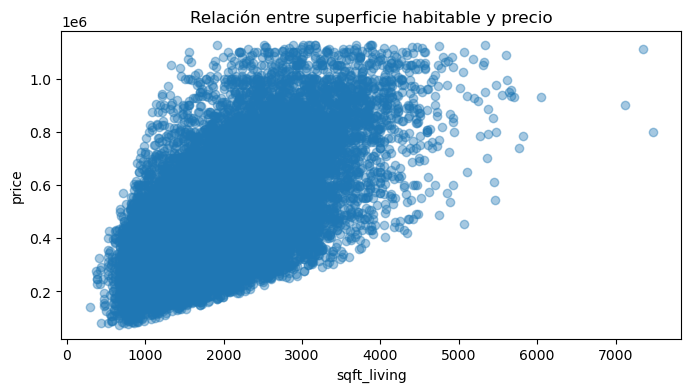

In [12]:
plt.figure(figsize=(8, 4))
plt.scatter(df_clean["sqft_living"], df_clean["price"], alpha=0.4)
plt.title("Relación entre superficie habitable y precio")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

en este caso, si bien a mayor cantidad de espacio habitable sube el precio, no hay una distribucion lineal en el precio de las casas segun su cantidad de espacio habitable, aun asi se puede lograr ver que el precio minimo aumenta proporcionalmente a la cantidad de espacio que posea el hogar.

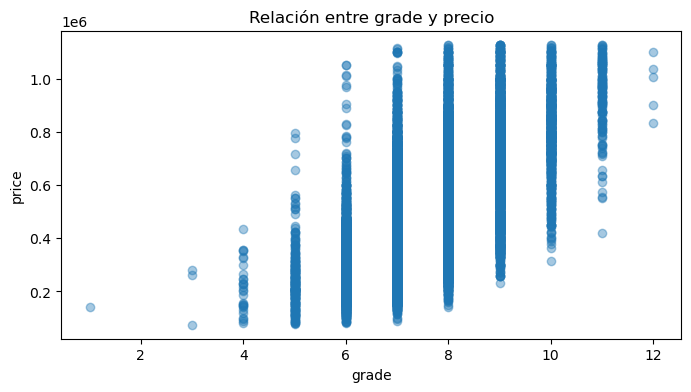

In [13]:
plt.figure(figsize=(8, 4))
plt.scatter(df_clean["grade"], df_clean["price"], alpha=0.4)
plt.title("Relación entre grade y precio")
plt.xlabel("grade")
plt.ylabel("price")
plt.show()

en esta grafica se puede apreciar mejor que a mayor grado, mayor el precio de la casa, por lo que se puede inferir que mientras mayor sea la calidad de la vivienda, mayor sera tambien el precio del hogar.

## 5. Análisis de correlaciones

Se calcula la correlación entre las variables numéricas y el precio.  
Esto permite identificar qué variables tienen mayor relación lineal con el precio de venta.

In [14]:
corr_price = df_clean.corr(numeric_only=True)["price"].sort_values(ascending=False)
corr_price

price            1.000000
grade            0.631182
sqft_living      0.622333
sqft_living15    0.562090
sqft_above       0.530451
bathrooms        0.455927
lat              0.430762
bedrooms         0.296956
floors           0.273987
view             0.238268
sqft_basement    0.235701
sqft_lot         0.093950
yr_renovated     0.083601
sqft_lot15       0.082420
long             0.070863
yr_built         0.061144
waterfront       0.051449
condition        0.038275
sale_year        0.002037
sale_month      -0.013449
zipcode         -0.018511
Name: price, dtype: float64

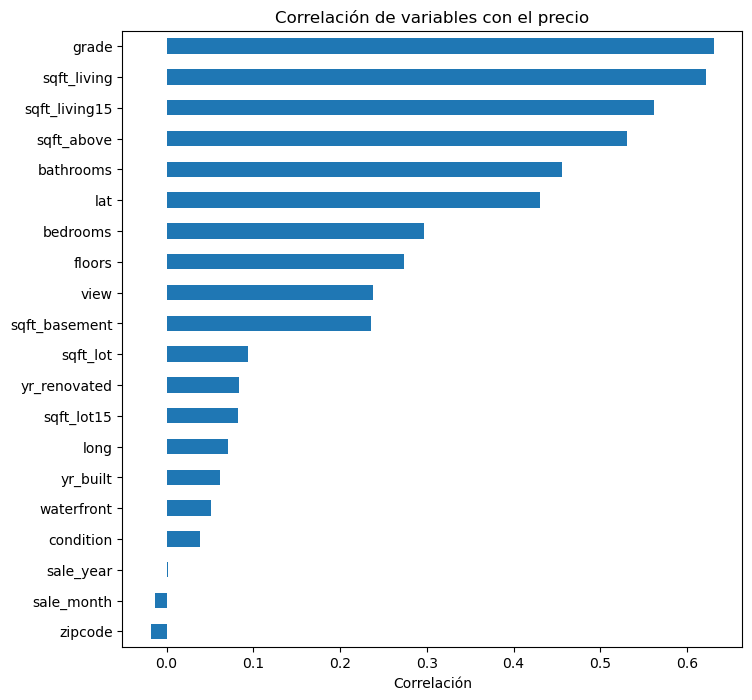

In [15]:
plt.figure(figsize=(8, 8))
corr_price.drop("price").sort_values().plot(kind="barh")
plt.title("Correlación de variables con el precio")
plt.xlabel("Correlación")
plt.show()

### Comentario sobre correlaciones

Las variables que normalmente tienen mayor correlación positiva con el precio son aquellas relacionadas con el tamaño y calidad de la vivienda, como `sqft_living`, `grade`, `sqft_above`, `bathrooms` y `sqft_living15`.

Esto tiene sentido, ya que propiedades más grandes, con mejor calificación y mejores características estructurales suelen tener precios más altos.

## 6. Preparación de variables

Se separa la variable objetivo `price` de las variables predictoras.

In [16]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


## 7. División en entrenamiento y prueba

Se deja un 33% de los datos para test, tal como solicita el desafío.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33, #porcentaje de datos que utilizaremos para testear
    random_state=42
)

X_train.shape, X_test.shape

((13712, 20), (6755, 20))

## 8. Pipeline de preprocesamiento

Se identifican las columnas numéricas y categóricas.  
En este dataset la mayoría de variables son numéricas, pero se mantiene una estructura robusta para evitar problemas si aparecen variables categóricas.

La estandarización se ajusta solamente con los datos de entrenamiento, y luego se aplica a test mediante el pipeline.

In [19]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
## como solo estamos trabajando con variables numericas, cat_cols no sera necesaria para este desafio.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols)
], remainder="drop")

num_cols, cat_cols

(['bedrooms',
  'bathrooms',
  'sqft_living',
  'sqft_lot',
  'floors',
  'waterfront',
  'view',
  'condition',
  'grade',
  'sqft_above',
  'sqft_basement',
  'yr_built',
  'yr_renovated',
  'zipcode',
  'lat',
  'long',
  'sqft_living15',
  'sqft_lot15'],
 [])

## 9. Definición de modelos e hiperparámetros

Se implementan los modelos solicitados:

- Ridge
- Lasso
- Elastic Net
- Árbol de Regresión

Además, se utiliza `GridSearchCV` para buscar los mejores hiperparámetros.

In [21]:
modelos = {
    "Ridge": { # regresion lineal que evita que los coeficientes se vuelvan muy grandes.
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10] #mientras mayor el alfa, mayor el "castigo" hacia el modelo
        }
    },
    "Lasso": { #regresion lineal que intenta quedarse con las variables mas representativas.
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", Lasso(max_iter=10000))
        ]),
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10]
        }
    },
    "ElasticNet": { #modelo intermedio entre los anteriores, fuciona ambas metodologias de una manera mas equilibrada.
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", ElasticNet(max_iter=10000))
        ]),
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },
    "DecisionTreeRegressor": { #divide los datos en reglas, sigue evaluando las que no caigan su regla de "stop"
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeRegressor(random_state=42))
        ]),
        "params": { #aqui controlamos que tan complejo queremos que se vuelva el arbol de desiciones.
            "model__max_depth": [None, 10, 20, 30],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    }
}

## 10. Entrenamiento y evaluación de modelos

Para cada modelo se realiza:

1. Búsqueda de hiperparámetros con validación cruzada.
2. Entrenamiento con los mejores parámetros.
3. Predicción sobre el conjunto de prueba.
4. Cálculo de métricas: MAE, MSE, RMSE y R².

In [22]:
resultados = []
mejores_modelos = {}

for nombre, config in modelos.items():
    print(f"Entrenando modelo: {nombre}")

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    mejor_modelo = grid.best_estimator_
    mejores_modelos[nombre] = mejor_modelo

    y_pred = mejor_modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "Modelo": nombre,
        "Best Params": grid.best_params_,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)
resultados_df

Entrenando modelo: Ridge
Entrenando modelo: Lasso
Entrenando modelo: ElasticNet
Entrenando modelo: DecisionTreeRegressor


,Modelo,Best Params,MAE,MSE,RMSE,R2
3,DecisionTreeRegressor,"{'model__max_depth': 10, 'model__min_samples_l...",67567.182629,9.358047e+09,96737.001156,0.777795
2,ElasticNet,"{'model__alpha': 0.01, 'model__l1_ratio': 0.7}",86735.627766,1.319619e+10,114874.682371,0.686659
0,Ridge,{'model__alpha': 10},86749.803020,1.319854e+10,114884.881881,0.686604
1,Lasso,{'model__alpha': 10},86751.879703,1.319878e+10,114885.929812,0.686598


## 11. Visualización comparativa de métricas

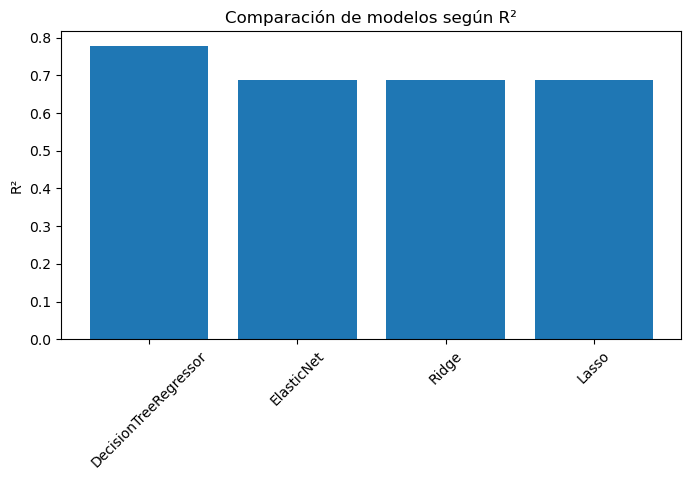

In [23]:
plt.figure(figsize=(8, 4))
plt.bar(resultados_df["Modelo"], resultados_df["R2"])
plt.title("Comparación de modelos según R²")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

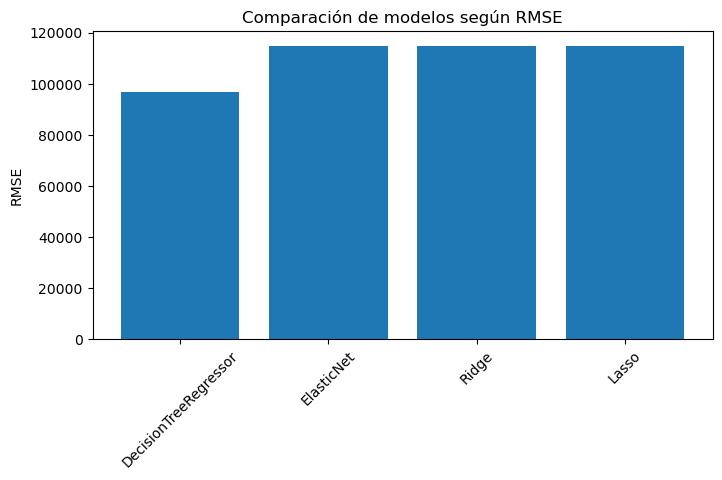

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(resultados_df["Modelo"], resultados_df["RMSE"])
plt.title("Comparación de modelos según RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

## 12. Análisis de hiperparámetros

Se elige el modelo Ridge para analizar cómo varía el rendimiento según el valor de `alpha`.

`alpha` controla la fuerza de la regularización:
- valores bajos permiten mayor flexibilidad;
- valores altos penalizan más los coeficientes.

In [25]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="r2",
    return_train_score=True
)

ridge_grid.fit(X_train, y_train)

ridge_results = pd.DataFrame(ridge_grid.cv_results_)
ridge_results[["param_model__alpha", "mean_train_score", "mean_test_score"]]

,param_model__alpha,mean_train_score,mean_test_score
0,0.001,0.701333,0.699710
1,0.010,0.701333,0.699710
2,0.100,0.701333,0.699710
3,1.000,0.701333,0.699711
4,10.000,0.701332,0.699714


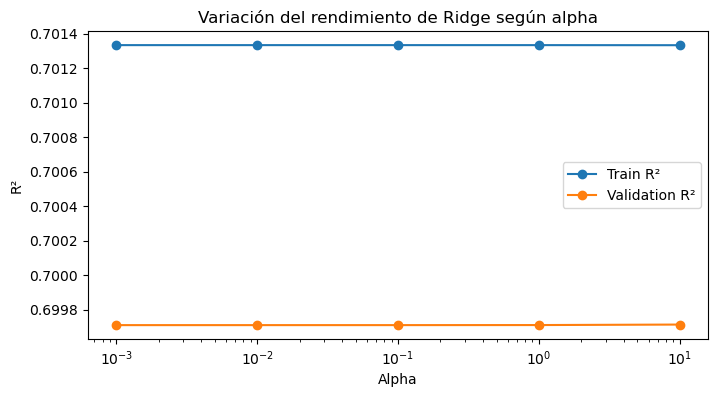

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(
    ridge_results["param_model__alpha"].astype(float),
    ridge_results["mean_train_score"],
    marker="o",
    label="Train R²"
)
plt.plot(
    ridge_results["param_model__alpha"].astype(float),
    ridge_results["mean_test_score"],
    marker="o",
    label="Validation R²"
)
plt.xscale("log")
plt.title("Variación del rendimiento de Ridge según alpha")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.legend()
plt.show()

## 13. Predicción vs valor real del mejor modelo

Se grafica el precio real contra el precio predicho para observar visualmente qué tan cerca están las predicciones.

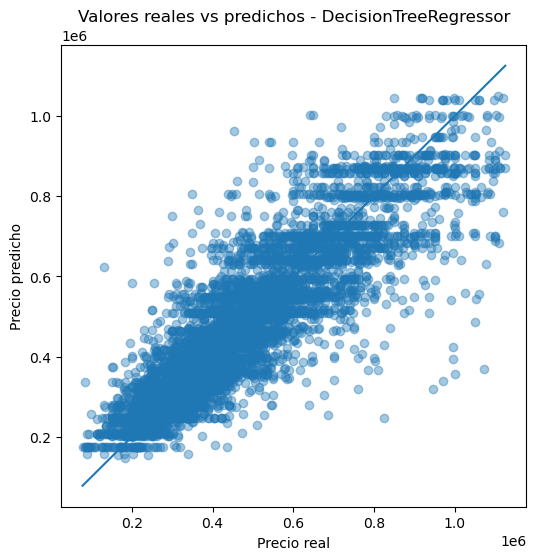

Mejor modelo: DecisionTreeRegressor


In [27]:
mejor_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = mejores_modelos[mejor_nombre]

y_pred_mejor = mejor_modelo.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_mejor, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"Valores reales vs predichos - {mejor_nombre}")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.show()

print("Mejor modelo:", mejor_nombre)

Esto sugiere que la relación entre las variables y el precio de las casas no es completamente lineal, por lo que el árbol logra capturar mejor patrones complejos en los datos.

Sin embargo, es importante considerar que los modelos de árbol pueden sobreajustarse a los datos de entrenamiento, por lo que sería recomendable validar su desempeño con técnicas adicionales o conjuntos de datos nuevos.

## 14. Conclusiones

A partir de la comparación de modelos, se selecciona como mejor alternativa aquel que obtiene mayor R² y menor RMSE en el conjunto de prueba.

El modelo Decision Tree Regressor obtuvo el mejor rendimiento, alcanzando el mayor valor de R² y el menor RMSE en comparación con los modelos lineales. Esto indica que logra explicar mejor la variabilidad del precio de las viviendas y comete menores errores en sus predicciones.

Este resultado sugiere que las relaciones entre las variables predictoras y el precio no son completamente lineales, lo que favorece el uso de modelos capaces de capturar patrones complejos, como los árboles de decisión.

No obstante, se debe tener precaución con el posible sobreajuste del modelo, por lo que sería recomendable evaluar su generalización en nuevos datos.

En general, las variables más relacionadas con el precio son las asociadas al tamaño, calidad y características estructurales de la vivienda, lo cual es coherente con el problema inmobiliario.